In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = Path("../data/results")
CI_FILES = list(BASE_PATH.glob("*-ci.json"))

print(f"Archivos CI encontrados: {len(CI_FILES)}")

Archivos CI encontrados: 2


In [ ]:
data = []

for file in CI_FILES:
    repo_name = file.stem.replace("-ci", "")

    with open(file, "r", encoding="utf-8") as f:
        content = json.load(f)

    for issue in content.get("issues", []):
        data.append({
            "repo": repo_name,
            "check_id": issue.get("check_id"),
            "check_name": issue.get("check_name"),
            "severity": issue.get("severity") or "UNKNOWN",
            "file": issue.get("file"),
        })

df = pd.DataFrame(data)

df.head()

,repo,check_id,check_name,severity,file
0,Flowise,CKV_GHA_7,The build output cannot be affected by user pa...,UNKNOWN,/docker-image-dockerhub.yml
1,Flowise,CKV_GHA_7,The build output cannot be affected by user pa...,UNKNOWN,/docker-image-ecr.yml
2,Flowise,CKV_GHA_7,The build output cannot be affected by user pa...,UNKNOWN,/proprietary-path-guard.yml
3,Flowise,CKV_GHA_7,The build output cannot be affected by user pa...,UNKNOWN,/publish-agentflow.yml
4,Flowise,CKV2_GHA_1,Ensure top-level permissions are not set to wr...,UNKNOWN,/docker-image-dockerhub.yml


In [4]:
issues_per_repo = df.groupby("repo").size().sort_values(ascending=False)

issues_per_repo

repo
Flowise             7
FlowiseChatEmbed    2
dtype: int64

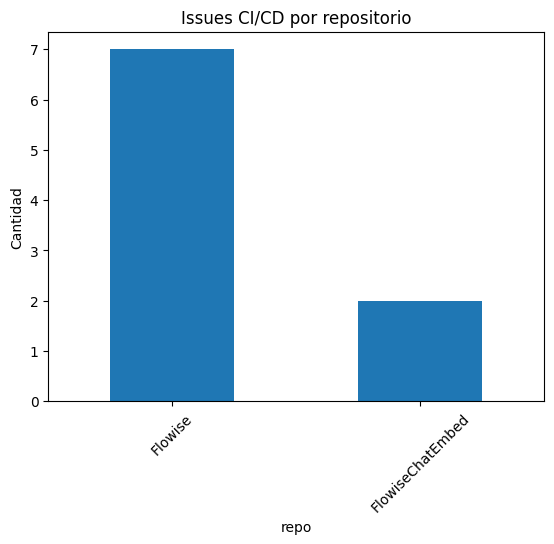

In [5]:
issues_per_repo.plot(kind="bar")
plt.title("Issues CI/CD por repositorio")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

In [6]:
pivot = pd.crosstab(df["repo"], df["check_id"])

pivot

check_id,CKV2_GHA_1,CKV_GHA_7
repo,,
Flowise,3,4
FlowiseChatEmbed,1,1


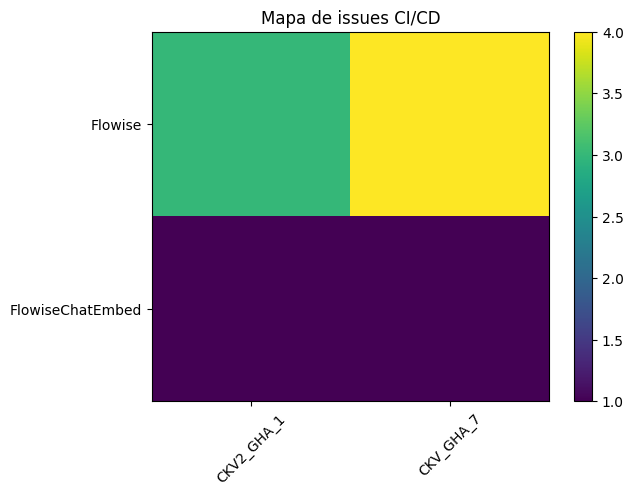

In [7]:
plt.imshow(pivot, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Mapa de issues CI/CD")
plt.colorbar()
plt.show()

In [8]:
all_repos = [p.name for p in Path("../data/repos").iterdir() if p.is_dir()]
repos_with_ci = df["repo"].unique().tolist()

coverage = {
    "total_repos": len(all_repos),
    "repos_with_ci": len(repos_with_ci),
    "repos_without_ci": len(set(all_repos) - set(repos_with_ci))
}

coverage

{'total_repos': 5, 'repos_with_ci': 2, 'repos_without_ci': 3}

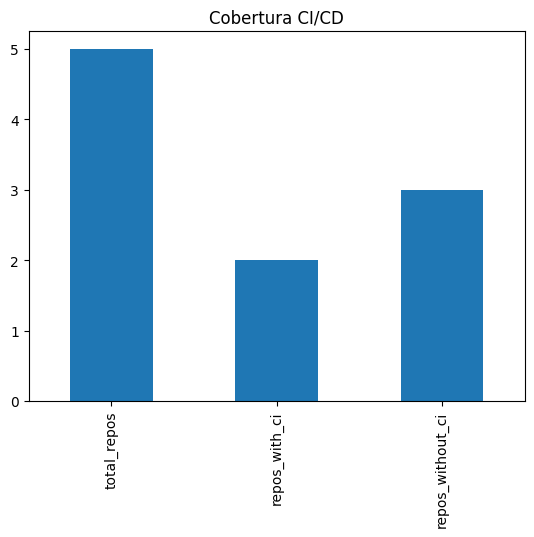

In [9]:
pd.Series(coverage).plot(kind="bar")
plt.title("Cobertura CI/CD")
plt.show()

In [10]:
write_all_issues = df[df["check_id"] == "CKV2_GHA_1"]

write_all_issues

,repo,check_id,check_name,severity,file
4,Flowise,CKV2_GHA_1,Ensure top-level permissions are not set to wr...,UNKNOWN,/docker-image-dockerhub.yml
5,Flowise,CKV2_GHA_1,Ensure top-level permissions are not set to wr...,UNKNOWN,/publish-agentflow.yml
6,Flowise,CKV2_GHA_1,Ensure top-level permissions are not set to wr...,UNKNOWN,/test_docker_build.yml
8,FlowiseChatEmbed,CKV2_GHA_1,Ensure top-level permissions are not set to wr...,UNKNOWN,/publish.yml


El análisis de CI/CD identifica dos configuraciones inseguras principales en los workflows de GitHub Actions:

CKV2_GHA_1: uso de permisos excesivos (permissions: write-all), lo que otorga más privilegios de los necesarios y aumenta el riesgo de comprometer el repositorio.
CKV_GHA_7: uso de workflow_dispatch con inputs no restringidos, permitiendo influir en la ejecución del pipeline de forma potencialmente maliciosa.

En conjunto, estas debilidades reflejan problemas en el control de permisos y validación de entradas, incrementando el riesgo de ataques de supply chain en el pipeline.